In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lsind18/gemstones-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gemstones-images' dataset.
Path to dataset files: /kaggle/input/gemstones-images


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU found: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("No GPU found. Training will run on CPU.")

GPU found: /physical_device:GPU:0


In [ ]:
import os
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow as tf # Ensure tf is imported for tf.cast

# Define the base directory for the dataset
dataset_base_path = path # 'path' comes from the kagglehub download cell

# Create training and validation datasets
# Assuming the dataset structure is 'dataset_base_path/train/class_name/image.jpg'
# and 'dataset_base_path/test/class_name/image.jpg' or similar

image_size = (224, 224) # Inception models typically use 224x224 or 299x299
batch_size = 32

# Check for 'train' and 'test' subdirectories
if os.path.isdir(os.path.join(dataset_base_path, 'train')) and os.path.isdir(os.path.join(dataset_base_path, 'test')):
    train_dir = os.path.join(dataset_base_path, 'train')
    test_dir = os.path.join(dataset_base_path, 'test')
    print(f"Found train directory: {train_dir}")
    print(f"Found test directory: {test_dir}")

    train_ds = image_dataset_from_directory(
        train_dir,
        labels='inferred',
        label_mode='int',
        image_size=image_size,
        interpolation='nearest',
        batch_size=batch_size,
        shuffle=True,
        seed=42
    )

    val_ds = image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=image_size,
        interpolation='nearest',
        batch_size=batch_size,
        shuffle=False,
        seed=42
    )

elif os.path.isdir(dataset_base_path):
    # If no explicit train/test split, try to create from the main directory
    print(f"Attempting to create train/validation split from: {dataset_base_path}")
    train_ds = image_dataset_from_directory(
        dataset_base_path,
        labels='inferred',
        label_mode='int',
        image_size=image_size,
        interpolation='nearest',
        batch_size=batch_size,
        shuffle=True,
        validation_split=0.2, # 20% for validation
        subset='training',
        seed=42
    )

    val_ds = image_dataset_from_directory(
        dataset_base_path,
        labels='inferred',
        label_mode='int',
        image_size=image_size,
        interpolation='nearest',
        batch_size=batch_size,
        shuffle=False,
        validation_split=0.2,
        subset='validation',
        seed=42
    )
else:
    raise FileNotFoundError("Dataset directory not found or structure not as expected.")

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data Augmentation and Normalization
# InceptionV2 (and InceptionResNetV2) expects input pixels in the range [-1, 1]
# Keras applications generally include their own preprocessing, so we'll use a simple scaling first.

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
])

preprocess_input = tf.keras.applications.inception_resnet_v2.preprocess_input

def prepare_data(image, label):
    image = tf.cast(image, tf.float32) # Cast image to float32
    image = data_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label

# Apply preprocessing to datasets
train_ds = train_ds.map(prepare_data, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda image, label: (preprocess_input(tf.cast(image, tf.float32)), label), num_parallel_calls=AUTOTUNE) # Cast image to float32 for validation set

print("Dataset preparation complete.")

Found train directory: /kaggle/input/gemstones-images/train
Found test directory: /kaggle/input/gemstones-images/test
Found 2856 files belonging to 87 classes.
Found 363 files belonging to 87 classes.
Number of classes: 87
Class names: ['Alexandrite', 'Almandine', 'Amazonite', 'Amber', 'Amethyst', 'Ametrine', 'Andalusite', 'Andradite', 'Aquamarine', 'Aventurine Green', 'Aventurine Yellow', 'Benitoite', 'Beryl Golden', 'Bixbite', 'Bloodstone', 'Blue Lace Agate', 'Carnelian', 'Cats Eye', 'Chalcedony', 'Chalcedony Blue', 'Chrome Diopside', 'Chrysoberyl', 'Chrysocolla', 'Chrysoprase', 'Citrine', 'Coral', 'Danburite', 'Diamond', 'Diaspore', 'Dumortierite', 'Emerald', 'Fluorite', 'Garnet Red', 'Goshenite', 'Grossular', 'Hessonite', 'Hiddenite', 'Iolite', 'Jade', 'Jasper', 'Kunzite', 'Kyanite', 'Labradorite', 'Lapis Lazuli', 'Larimar', 'Malachite', 'Moonstone', 'Morganite', 'Onyx Black', 'Onyx Green', 'Onyx Red', 'Opal', 'Pearl', 'Peridot', 'Prehnite', 'Pyrite', 'Pyrope', 'Quartz Beer', 'Quar

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.optimizers import Adam

# Load the InceptionResNetV2 model with pre-trained ImageNet weights
# Exclude the top classification layer
base_model = InceptionResNetV2(input_shape=(image_size[0], image_size[1], 3),
                               include_top=False,
                               weights='imagenet')

# Freeze the convolutional base to prevent weights from being updated during initial training
base_model.trainable = False

# Create a new model on top of the pre-trained base
inputs = tf.keras.Input(shape=(image_size[0], image_size[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Add a dropout layer for regularization
outputs = layers.Dense(num_classes, activation='softmax')(x) # Output layer with softmax for multi-class classification

model = models.Model(inputs, outputs)

# Compile the model
initial_learning_rate = 0.0001
optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

print("Model compilation complete.")

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_resnet_v2             │ (None, 5, 5, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 87)             │       133,719 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,470,455 (207.79 MB)

 Trainable params: 133,719 (522.34 KB)

 Non-trainable params: 54,336,736 (207.28 MB)

Model compilation complete.


In [ ]:
epochs = 20 # You can adjust the number of epochs

history = model.fit(train_ds,
                    epochs=epochs,
                    validation_data=val_ds)

print("Model training complete.")

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 120s 857ms/step - accuracy: 0.0165 - loss: 4.7551 - val_accuracy: 0.0634 - val_loss: 4.2710
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 461ms/step - accuracy: 0.0480 - loss: 4.2181 - val_accuracy: 0.1240 - val_loss: 3.8750
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 83s 471ms/step - accuracy: 0.1169 - loss: 3.7888 - val_accuracy: 0.2121 - val_loss: 3.5557
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 458ms/step - accuracy: 0.1842 - loss: 3.4899 - val_accuracy: 0.2452 - val_loss: 3.3083
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 458ms/step - accuracy: 0.2468 - loss: 3.2293 - val_accuracy: 0.2672 - val_loss: 3.0998
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 456ms/step - accuracy: 0.2875 - loss: 3.0113 - val_accuracy: 0.3058 - val_loss: 2.9410
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 42s 465ms/step - accuracy: 0.3225 - loss: 2.8636 - val_accuracy: 0.3278 - val_loss: 2.7987
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 468ms/step - accuracy: 0.3610 - loss: 2.7037 - val_acc

In [ ]:
import pandas as pd

hist_df = pd.DataFrame(history.history)
display(hist_df)

print(f"\nFinal Training Accuracy: {hist_df['accuracy'].iloc[-1]:.4f}")
print(f"Final Validation Accuracy: {hist_df['val_accuracy'].iloc[-1]:.4f}")
print(f"Final Training Loss: {hist_df['loss'].iloc[-1]:.4f}")
print(f"Final Validation Loss: {hist_df['val_loss'].iloc[-1]:.4f}")

,accuracy,loss,val_accuracy,val_loss
0,0.016457,4.755146,0.063361,4.270969
1,0.047969,4.218102,0.123967,3.875043
2,0.116947,3.788773,0.212121,3.555744
3,0.184174,3.489889,0.245179,3.308285
4,0.246849,3.229267,0.267218,3.099815
5,0.287465,3.011269,0.305785,2.940951
6,0.322479,2.863613,0.327824,2.798686
7,0.360994,2.703698,0.325069,2.688381
8,0.372899,2.583459,0.344353,2.585276
9,0.400560,2.470310,0.377410,2.499931



Final Training Accuracy: 0.5315
Final Validation Accuracy: 0.4353
Final Training Loss: 1.8213
Final Validation Loss: 2.0549


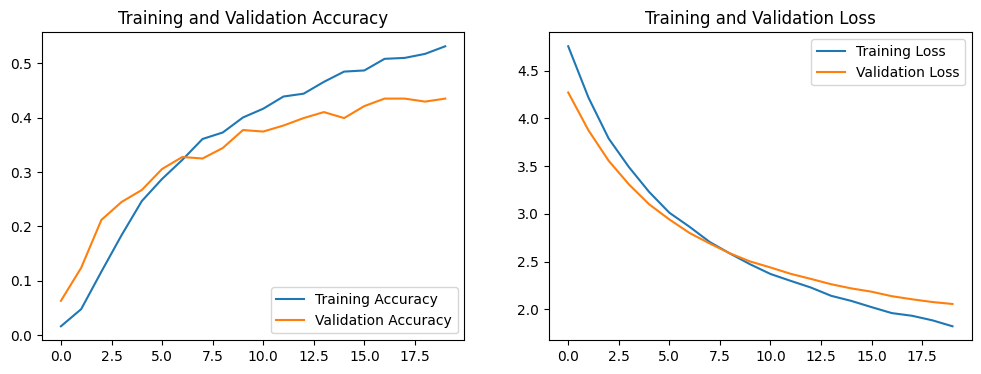

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()